In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# This script get the database of events with Odometer that I created in my research.
events=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\events.csv',sep=';')
events_with_odometer=events[events['Odometer'].str.contains('Y')]
df_book_table01=events_with_odometer

In [3]:
raw_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\chilco\wnm396.csv',sep=',')
raw_data_columns=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\chilco\wnm396c.csv',sep=',')
raw_data_columns['Date']='NaN'
raw_data_columns['Message_Type']='NaN'
raw_data_columns['Message_Type_No_Buff']='NaN'
aux_m=[]
aux_m_nb=[]

for i in range(0,raw_data_columns.shape[0]):
    aux_m.append(raw_data_columns.iloc[i,0][6:11])
    #aux_m_nb.append(raw_data_columns.iloc[i,0])
raw_data_columns['Message_Type']=aux_m

raw_data_columns['Message_Type'].value_counts().to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\chilco\columns.csv')
raw_data_columns_aux=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\chilco\columns.csv')
raw_data_columns_aux.info()
df_book_table02=raw_data_columns_aux

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Message_Type  14 non-null     str  
 1   count         14 non-null     int64
dtypes: int64(1), str(1)
memory usage: 356.0 bytes


In [4]:
raw_data_columns['Message_Type'].value_counts()

Message_Type
GTFRI    19025
GTSTT     3227
GTIGL      585
GTPDP      539
GTIGN      300
GTIGF      292
GTPFA        5
GTPNA        5
GTDOG        5
GTRTL        5
GTTOW        5
GTHBM        4
GTIDN        1
GTIDF        1
Name: count, dtype: int64

In [5]:
df_book_table01.info()
df_book_table02.info()

<class 'pandas.DataFrame'>
Index: 10 entries, 0 to 12
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Message   10 non-null     str  
 1   Odometer  10 non-null     str  
dtypes: str(2)
memory usage: 240.0 bytes
<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Message_Type  14 non-null     str  
 1   count         14 non-null     int64
dtypes: int64(1), str(1)
memory usage: 356.0 bytes


In [6]:
num_filas_table01=int(df_book_table01.shape[0])
num_filas_table02=int(df_book_table02.shape[0])       
cont=0
df_aux=pd.DataFrame()        
list_field01=[]
list_field02=[]
#list_field03=[]
#list_field04=[]       
#print("df_book_table01[8,0]: ",df_book_table01.iloc[8,0]) #UnitsByDealer.csv_r.csv
#print("df_book_table02[8,5]: ",df_book_table02.iloc[8,5]) #6MB.        
#print("\nInformación de las tablas: ")
#print("\nTabla 1:")
#print(df_book_table01.info())
#print("\nTabla 2:")
#print(df_book_table02.info())
attribute_name_table01='Message'#Digitar el índice de la tabla 1.#input("\nDigita el atributo a comparar de la tabla 1: ")
attribute_name_table02='Message_Type'#Digitar el índice de la tabla 2.#input("Digita el atribito a comparar de la tabla 2: ")
position_table01=int(df_book_table01.columns.get_loc(attribute_name_table01))
position_table02=int(df_book_table02.columns.get_loc(attribute_name_table02))
print("\nAtributo de la tabla1: ",position_table01)
print("Atributo de la tabla2: ",position_table02,"\n")
print("Trabajando...")                          
for i in range(0,num_filas_table01):
    for j in range(0,num_filas_table02):
        #if str(df_book_table01.iloc[i,5])==str(df_book_table02.iloc[j,3]): 
        if str(df_book_table01.iloc[i,position_table01])==str(df_book_table02.iloc[j,position_table02]):                                                                             
            list_field01.append(df_book_table01.iloc[i,0])
            list_field02.append(df_book_table01.iloc[i,1])
            #list_field03.append(df_book_table02.iloc[j,21])
            #list_field04.append(df_book_table02.iloc[j,3])
            print("df_book_table01[i,position_table01]: ",df_book_table01.iloc[i,position_table01]," = ",end="")
            print("df_book_table02[j,position_table02]: ",df_book_table02.iloc[j,position_table02])               
            cont=cont+1
df_aux['Message']=list_field01
df_aux['Odometer']=list_field02
#df_aux['MSISDN']=list_field03
#df_aux['Last Contact On']=list_field04
print("Cont= ",cont)
print(df_aux.info())
option_exp=input("\n¿Desea generar un reporte de coincidencias en formato csv S/N?\n")
if option_exp=="S":
    df_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\chilco\coincidences.csv')                  #Edit
cont=0
option_exp=input("¿Desea generar un reporte de diferencias en formato csv S/N?\n")        
df_book_table02['ACTION']="Keep"
if option_exp=="S":
    print("Trabajando...")
    for i in range(0,num_filas_table01):
        for j in range(0,num_filas_table02):
            if str(df_book_table01.iloc[i,position_table01])==str(df_book_table02.iloc[j,position_table02]):
                df_book_table02.iloc[j,2]=np.nan                                                                    #Edit
                print("df_book_table01[i,position_table01]: ",df_book_table01.iloc[i,position_table01]," = ",end="")
                print("df_book_table02[j,position_table02]: ",df_book_table02.iloc[j,position_table02])               
    #print(df_book_table02)
    df_book_table02.dropna(axis=0,inplace=True)
    print(df_book_table02)
    df_book_table02.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\chilco\diffrences')          #Edit

df_aux


Atributo de la tabla1:  0
Atributo de la tabla2:  0 

Trabajando...
df_book_table01[i,position_table01]:  GTFRI  = df_book_table02[j,position_table02]:  GTFRI
df_book_table01[i,position_table01]:  GTIGL  = df_book_table02[j,position_table02]:  GTIGL
df_book_table01[i,position_table01]:  GTIGF  = df_book_table02[j,position_table02]:  GTIGF
df_book_table01[i,position_table01]:  GTIGN  = df_book_table02[j,position_table02]:  GTIGN
df_book_table01[i,position_table01]:  GTIDN  = df_book_table02[j,position_table02]:  GTIDN
df_book_table01[i,position_table01]:  GTIDF  = df_book_table02[j,position_table02]:  GTIDF
df_book_table01[i,position_table01]:  GTHBM  = df_book_table02[j,position_table02]:  GTHBM
df_book_table01[i,position_table01]:  GTRTL  = df_book_table02[j,position_table02]:  GTRTL
df_book_table01[i,position_table01]:  GTDOG  = df_book_table02[j,position_table02]:  GTDOG
Cont=  9
<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 2 columns):
 #   Column   

,Message,Odometer
0,GTFRI,Y
1,GTIGL,Y
2,GTIGF,Y
3,GTIGN,Y
4,GTIDN,Y
5,GTIDF,Y
6,GTHBM,Y
7,GTRTL,Y
8,GTDOG,Y


kok936

In [8]:
gtfri_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTFRI')]
gtigl_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTIGL')]
gtigf_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTIGF')]
gtign_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTIGN')]
#gttow_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTTOW')]
gtrtl_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTRTL')]
gtdog_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTDOG')]
#gtspd_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTSPD')]
gtidn_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTIDN')]
gtidf_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTIDF')]
gthbm_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTHBM')]
#gtbtc_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTBTC')]
#gtstc_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTSTC')]
#gtstt_raw_data=raw_data_columns[raw_data_columns['Message'].str.contains('GTSTT')]

date_gtfri=[]
date_gtigl=[]
date_gtigf=[]
date_gtign=[]
date_gthbm=[]
date_gttow=[]
date_gtrtl=[]
date_gtdog=[]
date_gtspd=[]
date_gtidn=[]
date_gtidf=[]
date_gtbtc=[]
date_gtstc=[]
date_gtstt=[]

km_gtfri=[]
km_gtigl=[]
km_gtign=[]
km_gtigf=[]
km_gtidn=[]
km_gtidf=[]
km_gtdog=[]
km_gtspd=[]
km_gtrtl=[]
km_gthbm=[]
km_gttow=[]
km_gtbtc=[]
km_gtstc=[]
km_gtstt=[]

sp_gtfri=[]
sp_gtigl=[]
sp_gtign=[]
sp_gtigf=[]
sp_gtidn=[]
sp_gtidf=[]
sp_gtdog=[]
sp_gtspd=[]
sp_gtrtl=[]
sp_gthbm=[]
sp_gttow=[]
sp_gtspd=[]
sp_gtbtc=[]
sp_gtstc=[]
sp_gtstt=[]

for i in range(0, gtfri_raw_data.shape[0]):
    date_gtfri.append(str(gtfri_raw_data.iloc[i,13]))    
    km_gtfri.append((float(gtfri_raw_data.iloc[i,20]))*0.621371)
    sp_gtfri.append(gtfri_raw_data.iloc[i,8])
gtfri_raw_data['Date']=date_gtfri
gtfri_raw_data['Km in miles']=km_gtfri
gtfri_raw_data['Speed']=sp_gtfri

for i in range(0, gtigl_raw_data.shape[0]):
    date_gtigl.append(str(gtigl_raw_data.iloc[i,13]))    
    km_gtigl.append((float(gtigl_raw_data.iloc[i,20]))*0.621371)
    sp_gtigl.append(gtigl_raw_data.iloc[i,8])
gtigl_raw_data['Date']=date_gtigl
gtigl_raw_data['Km in miles']=km_gtigl
gtigl_raw_data['Speed']=sp_gtigl

for i in range(0, gtign_raw_data.shape[0]):
    date_gtign.append(str(gtign_raw_data.iloc[i,13]))    
    km_gtign.append((float(gtign_raw_data.iloc[i,20]))*0.621371)
    sp_gtign.append(gtign_raw_data.iloc[i,6])
gtign_raw_data['Date']=date_gtign
gtign_raw_data['Km in miles']=km_gtign
gtign_raw_data['Speed']=sp_gtign

for i in range(0, gtigf_raw_data.shape[0]):
    date_gtigf.append(str(gtigf_raw_data.iloc[i,13]))    
    km_gtigf.append((float(gtigf_raw_data.iloc[i,20]))*0.621371)
    sp_gtigf.append(gtigf_raw_data.iloc[i,6])
gtigf_raw_data['Date']=date_gtigf
gtigf_raw_data['Km in miles']=km_gtigf
gtigf_raw_data['Speed']=sp_gtigf

for i in range(0, gtidn_raw_data.shape[0]):
    date_gtidn.append(str(gtidn_raw_data.iloc[i,12]))    
    km_gtidn.append((float(gtidn_raw_data.iloc[i,20]))*0.621371)
    sp_gtidn.append(gtidn_raw_data.iloc[i,7])    
gtidn_raw_data['Date']=date_gtidn
gtidn_raw_data['Km in miles']=km_gtidn
gtidn_raw_data['Speed']=sp_gtidn

for i in range(0, gtidf_raw_data.shape[0]):
    date_gtidf.append(str(gtidf_raw_data.iloc[i,12]))    
    km_gtidf.append((float(gtidf_raw_data.iloc[i,20]))*0.621371)
    sp_gtidf.append(gtidf_raw_data.iloc[i,7])
gtidf_raw_data['Date']=date_gtidf
gtidf_raw_data['Km in miles']=km_gtidf

for i in range(0, gtdog_raw_data.shape[0]):
    date_gtdog.append(str(gtdog_raw_data.iloc[i,13]))    
    km_gtdog.append((float(gtdog_raw_data.iloc[i,20]))*0.621371)
    sp_gtdog.append(gtdog_raw_data.iloc[i,8])   
gtdog_raw_data['Date']=date_gtdog
gtdog_raw_data['Km in miles']=km_gtdog
gtdog_raw_data['Speed']=sp_gtdog

"""
for i in range(0, gtspd_raw_data.shape[0]):
    date_gtspd.append(str(gtspd_raw_data.iloc[i,13]))    
    km_gtspd.append((float(gtspd_raw_data.iloc[i,20]))*0.621371)
    sp_gtspd.append(gtspd_raw_data.iloc[i,8])    
gtspd_raw_data['Date']=date_gtspd
gtspd_raw_data['Km in miles']=km_gtspd
gtspd_raw_data['Speed']=sp_gtspd

"""

for i in range(0, gtrtl_raw_data.shape[0]):
    date_gtrtl.append(str(gtrtl_raw_data.iloc[i,13]))    
    km_gtrtl.append((float(gtrtl_raw_data.iloc[i,20]))*0.621371)
    sp_gtrtl.append(gtrtl_raw_data.iloc[i,8])
gtrtl_raw_data['Date']=date_gtrtl
gtrtl_raw_data['Km in miles']=km_gtrtl
gtrtl_raw_data['Speed']=sp_gtrtl

for i in range(0, gthbm_raw_data.shape[0]):
    date_gthbm.append(str(gthbm_raw_data.iloc[i,13]))    
    km_gthbm.append((float(gthbm_raw_data.iloc[i,20]))*0.621371)
    sp_gthbm.append(gthbm_raw_data.iloc[i,8])    
gthbm_raw_data['Date']=date_gthbm
gthbm_raw_data['Km in miles']=km_gthbm
gthbm_raw_data['Speed']=sp_gthbm

#For any reason, date is turned into float value.
"""
for i in range(0, gttow_raw_data.shape[0]):
    date_gttow.append(gttow_raw_data.iloc[i,13])
    km_gttow.append((float(gttow_raw_data.iloc[i,20]))*0.621371)
    sp_gttow.append(gttow_raw_data.iloc[i,8])
gttow_raw_data['Date']=str(date_gttow)
gttow_raw_data['Km in miles']=km_gttow
gttow_raw_data['Speed']=sp_gttow

for i in range(0, gtstt_raw_data.shape[0]):
    date_gtstt.append(gtstt_raw_data.iloc[i,13])
    #km_gtstt.append((float(gtstt_raw_data.iloc[i,20]))*0.621371)
    sp_gtstt.append(gtstt_raw_data.iloc[i,5])
gtstt_raw_data['Date']=str(date_gtstt)
#gtstt_raw_data['Km in miles']=km_gtstt
gtstt_raw_data['Speed']=sp_gtstt
"""
value_to_look=input('Type the last date to searh: ')

gtfri_raw_data_wanted=gtfri_raw_data[gtfri_raw_data['Date'].str.contains(value_to_look)]
gtigl_raw_data_wanted=gtigl_raw_data[gtigl_raw_data['Date'].str.contains(value_to_look)]
gtign_raw_data_wanted=gtign_raw_data[gtign_raw_data['Date'].str.contains(value_to_look)]
gtigf_raw_data_wanted=gtigf_raw_data[gtigf_raw_data['Date'].str.contains(value_to_look)]
gtidn_raw_data_wanted=gtidn_raw_data[gtidn_raw_data['Date'].str.contains(value_to_look)]
gtidf_raw_data_wanted=gtidf_raw_data[gtidf_raw_data['Date'].str.contains(value_to_look)]
gtdog_raw_data_wanted=gtdog_raw_data[gtdog_raw_data['Date'].str.contains(value_to_look)]
#gtspd_raw_data_wanted=gtspd_raw_data[gtspd_raw_data['Date'].str.contains(value_to_look)]
gtrtl_raw_data_wanted=gtrtl_raw_data[gtrtl_raw_data['Date'].str.contains(value_to_look)]
gthbm_raw_data_wanted=gthbm_raw_data[gthbm_raw_data['Date'].str.contains(value_to_look)]
#gttow_raw_data_wanted=gttow_raw_data[gttow_raw_data['Date'].str.contains(value_to_look)]
#gtstt_raw_data_wabted=gtstt_raw_data[gtstt_raw_data['Date'].str.contains(value_to_look)]



#print(gtfri_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']],'\n',gtigl_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']])
#print(gtign_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']],'\n',gtigf_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']])
#print(gtidn_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']],'\n',gtidf_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']])
#print(gtdog_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']],'\n',gtspd_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']])
#print(gtrtl_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']],'\n',gthbm_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']])
#print(gttow_raw_data_wanted[['Message','Date','Unnamed: 20','Km in miles']])

result=pd.concat([gtfri_raw_data_wanted,
                        gtigl_raw_data_wanted,
                        gtign_raw_data_wanted,
                        gtigf_raw_data_wanted,
                        gtidn_raw_data_wanted,
                        gtidf_raw_data_wanted,
                        gtdog_raw_data_wanted,
                        #gtspd_raw_data_wanted,
                        gtrtl_raw_data_wanted,
                        gthbm_raw_data_wanted,
                        #gttow_raw_data_wanted
                        ])
result

,Message,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Date,Message_Type,Message_Type_No_Buff,Km in miles,Speed
1,+RESP:GTFRI,500700,868574042784426,NaN,NaN,10,1.0,1.0,0.0,190.0,...,NaN,NaN,NaN,2.026060e+13,CFC6$,20260601003704.0,GTFRI,NaN,21370.812803,0.0
3,+RESP:GTFRI,500700,868574042784426,NaN,NaN,10,1.0,1.0,0.0,190.0,...,NaN,NaN,NaN,2.026060e+13,CFC8$,20260601013721.0,GTFRI,NaN,21370.812803,0.0
5,+RESP:GTFRI,500700,868574042784426,NaN,NaN,10,1.0,1.0,0.0,190.0,...,NaN,NaN,NaN,2.026060e+13,CFCA$,20260601023759.0,GTFRI,NaN,21370.812803,0.0
7,+RESP:GTFRI,500700,868574042784426,NaN,NaN,10,1.0,1.0,0.0,190.0,...,NaN,NaN,NaN,2.026060e+13,CFCC$,20260601033735.0,GTFRI,NaN,21370.812803,0.0
9,+RESP:GTFRI,500700,868574042784426,NaN,NaN,10,1.0,1.0,0.0,190.0,...,NaN,NaN,NaN,2.026060e+13,CFCE$,20260601043750.0,GTFRI,NaN,21370.812803,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19196,+RESP:GTRTL,500700,868574042784426,NaN,NaN,0,1.0,1.0,0.1,343.0,...,NaN,NaN,NaN,NaN,NaN,20260625020054.0,GTRTL,NaN,22175.612522,0.1
4002,+RESP:GTHBM,500700,868574042784426,NaN,NaN,5,1.0,0.0,42.8,111.0,...,NaN,NaN,NaN,NaN,NaN,20260605164835.0,GTHBM,NaN,21556.975555,42.8
4035,+RESP:GTHBM,500700,868574042784426,NaN,NaN,5,1.0,0.0,47.7,118.0,...,NaN,NaN,NaN,NaN,NaN,20260605164917.0,GTHBM,NaN,21557.348377,47.7
4046,+RESP:GTHBM,500700,868574042784426,NaN,NaN,5,1.0,0.0,41.9,46.0,...,NaN,NaN,NaN,NaN,NaN,20260605164929.0,GTHBM,NaN,21557.410514,41.9


In [9]:
result.info()

<class 'pandas.DataFrame'>
Index: 19626 entries, 1 to 23686
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Message               19626 non-null  str    
 1   Unnamed: 1            19626 non-null  int64  
 2   Unnamed: 2            19626 non-null  int64  
 3   Unnamed: 3            0 non-null      float64
 4   Unnamed: 4            1 non-null      float64
 5   Unnamed: 5            19625 non-null  str    
 6   Unnamed: 6            19626 non-null  float64
 7   Unnamed: 7            19626 non-null  float64
 8   Unnamed: 8            19626 non-null  float64
 9   Unnamed: 9            19626 non-null  float64
 10  Unnamed: 10           19626 non-null  float64
 11  Unnamed: 11           19626 non-null  float64
 12  Unnamed: 12           19626 non-null  float64
 13  Unnamed: 13           19626 non-null  float64
 14  Unnamed: 14           19455 non-null  str    
 15  Unnamed: 15           19455 non-nul

In [10]:
print("Max value: ",result['Unnamed: 20'].max(),"Min value: ",result['Unnamed: 20'].min())
print("Odometer difference betwwen June the 30th and June the 01: ",float(result['Unnamed: 20'].max())-float(result['Unnamed: 20'].min()))

Max value:  36010.5 Min value:  34393
Odometer difference betwwen June the 30th and June the 01:  1617.5


In [11]:
result_ordered=result.sort_values('Date',ascending=True)

0 19624 34393 36010.5 20260630231028.0


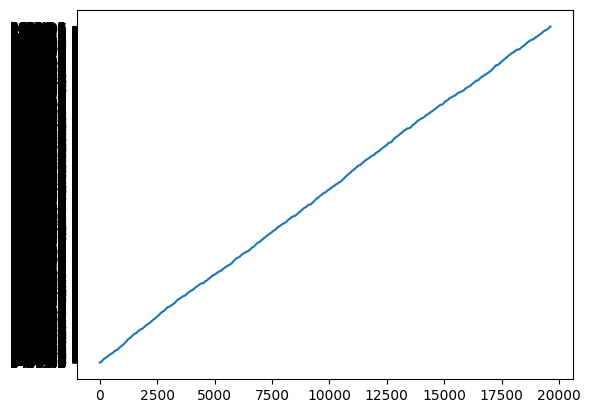

In [12]:
x_axis=[]
y_axis=[]
date_time=[]
for i in range(0,result_ordered.shape[0]-1):
    x_axis.append(i)
    y_axis.append(result_ordered.iloc[i,20])
    date_time.append(result_ordered.iloc[i,31])

print(min(x_axis),max(x_axis),min(y_axis),max(y_axis),date_time[max(x_axis)])

plt.plot(x_axis,y_axis)

0 19624 0.0 87.9 20260630231028.0


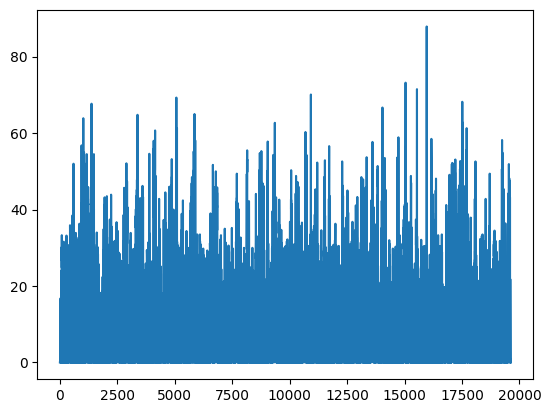

In [13]:
x_axis=[]
y_axis=[]
date_time=[]
for i in range(0,result_ordered.shape[0]-1):
    x_axis.append(i)
    y_axis.append(result_ordered.iloc[i,35])
    date_time.append(result_ordered.iloc[i,31])

print(min(x_axis),max(x_axis),min(y_axis),max(y_axis),date_time[max(x_axis)])

#plt.xticks(range(0,23282,1000),rotation=45)
#plt.yticks(range(0,285,50),rotation=45)
plt.plot(x_axis,y_axis)

¡Carlos Morante put a filter to keep raw data without  processing if the speed is very high!

In [14]:
for i in range(0,len(y_axis)):
    if y_axis[i]>100:
        print(y_axis[i],' -> ',date_time[i])